In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)

In [3]:
df = pd.read_csv("Air Traffic Data Stationary.csv",parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers_log_diff,international passenegrs_log_diff,domestic freight(in tonne)_log_diff,international freight(in tonne)_log_diff,GDP (in dollars)_log_diff,Population,Jet Fuel Price per Gallon_log_diff,Inflation Rate _log_diff,Unemployement Rate_log_diff,Rupees Exchange Rate_log_diff
Date,,,,,,,,,,
2009-01-02,0.001585,-0.156494,-0.110912,0.066838,0.0,1225524753,-0.146537,0.0,0.0,0.011230
2009-01-03,-0.053264,0.113350,0.211914,0.207414,0.0,1225524753,0.047891,0.0,0.0,0.037462
2009-01-04,0.045174,0.015990,-0.063735,-0.056726,0.0,1225524753,0.053022,0.0,0.0,-0.022949
2009-01-05,0.173060,0.041702,-0.101601,0.005086,0.0,1225524753,0.052154,0.0,0.0,-0.029653
2009-01-06,-0.063824,0.005875,0.149680,0.003217,0.0,1225524753,0.177301,0.0,0.0,-0.017468


ACF and PACF plots for Domestic Passengers

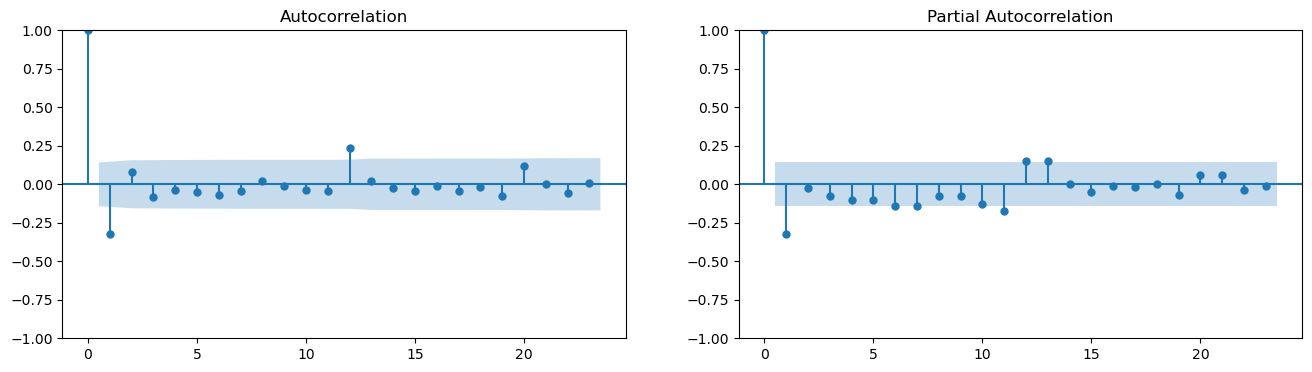

In [4]:
# Use ACF and PACF plots to find the best p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["domestic passengers_log_diff"], ax=axes[0])
plot_pacf(df["domestic passengers_log_diff"], ax=axes[1])
plt.show()

ACF and PACF for International Passengers

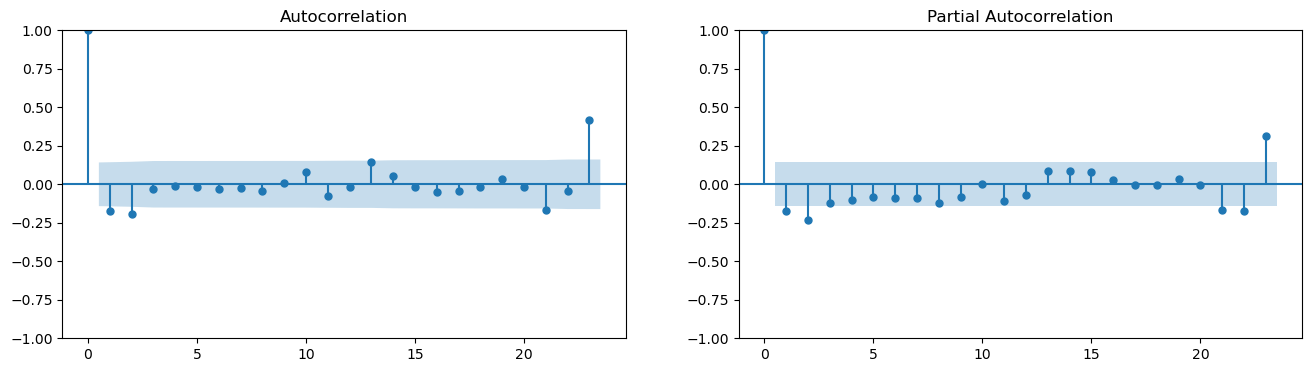

In [5]:
# Use ACF and PACF plots to find the best p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["international passenegrs_log_diff"], ax=axes[0])
plot_pacf(df["international passenegrs_log_diff"], ax=axes[1])
plt.show()

ACF and PACF for Domestic Freight

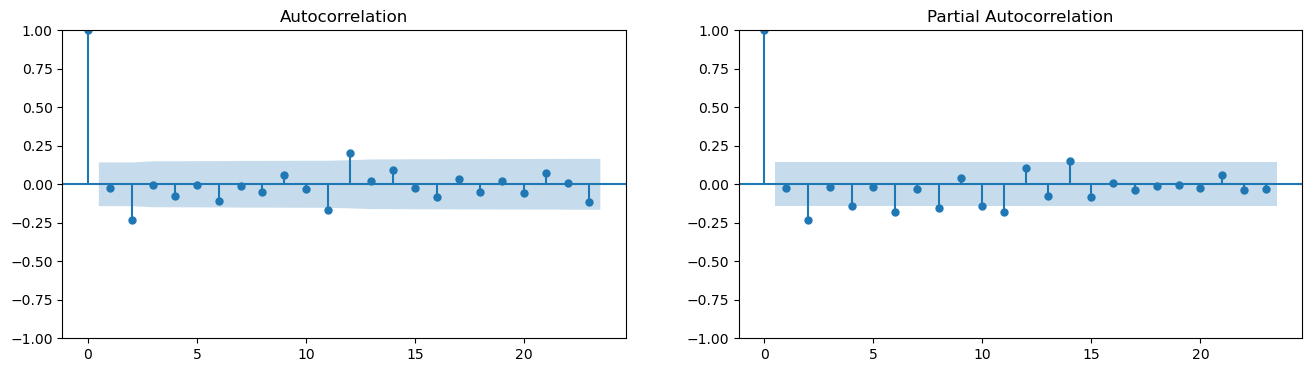

In [6]:
# Use ACF and PACF plots to find the best p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["domestic freight(in tonne)_log_diff"], ax=axes[0])
plot_pacf(df["domestic freight(in tonne)_log_diff"], ax=axes[1])
plt.show()

ACF and PACF plot for International Freight

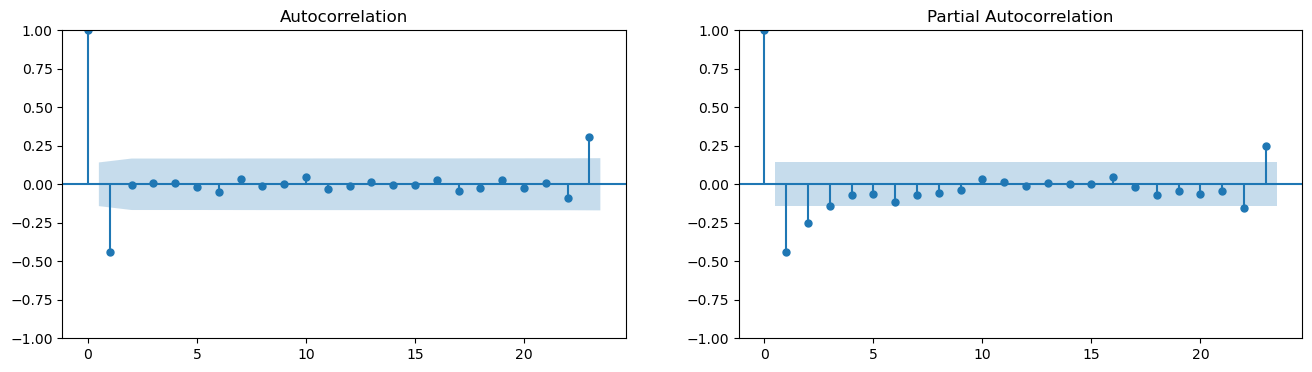

In [7]:
# Use ACF and PACF plots to find the best p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["international freight(in tonne)_log_diff"], ax=axes[0])
plot_pacf(df["international freight(in tonne)_log_diff"], ax=axes[1])
plt.show()

ACF and PACF for GDP

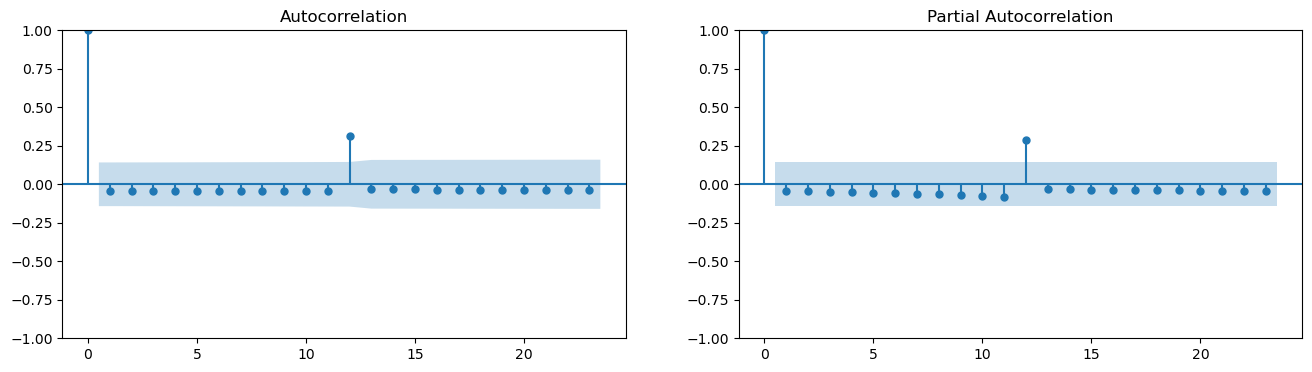

In [8]:
# Use ACF and PACF plots to find the best p and q
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df["GDP (in dollars)_log_diff"], ax=axes[0])
plot_pacf(df["GDP (in dollars)_log_diff"], ax=axes[1])
plt.show()

Since we had already applied first order differencing so we would consider d = 1

**Fitting the Model**

In [9]:
# Fit ARIMA(2,0,2)
model_202 = ARIMA(df["domestic passengers_log_diff"], order=(2,0,2))
result_202 = model_202.fit()
print(result_202.summary())

                                    SARIMAX Results                                     
Dep. Variable:     domestic passengers_log_diff   No. Observations:                  191
Model:                           ARIMA(2, 0, 2)   Log Likelihood                 -28.756
Date:                          Thu, 18 Sep 2025   AIC                             69.512
Time:                                  11:13:31   BIC                             89.026
Sample:                                       0   HQIC                            77.416
                                          - 191                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0062      0.004      1.526      0.127      -0.002       0.014
ar.L1          0.3456      0.523      0.661      0.

Finding the best parameters for ARIMA


In [10]:
stepwise_fit = auto_arima(
    df["domestic passengers_log_diff"], 
    seasonal=True,  
    trace=True,            # shows progress
    error_action="ignore",
    suppress_warnings=True
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=71.353, Time=0.32 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=97.833, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=78.641, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=78.260, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=95.958, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=81.544, Time=0.25 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.26 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.38 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.37 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=74.570, Time=0.18 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.59 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.36 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=74.329, Time=0.52 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=71.986, Time=0.19 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0] intercept
Total fit time: 3.612 seconds

In [11]:
model_002 = sm.tsa.ARIMA(df["domestic passengers_log_diff"], order=(0,0,2)).fit()
model_200 = sm.tsa.ARIMA(df["domestic passengers_log_diff"], order=(2,0,0)).fit()

In [12]:
print("AIC Comparison:")
print("ARIMA(2,0,2):", result_202.aic)
print("ARIMA(0,0,2):", model_002.aic)
print("ARIMA(2,0,0):", model_200.aic)

AIC Comparison:
ARIMA(2,0,2): 69.51242981117093
ARIMA(0,0,2): 80.24213695046339
ARIMA(2,0,0): 80.5052693711429


From the above AIC comparison we can say that the ARIMA(2,0,2) is the best model

**Model Evaluation**

Splitting the data into train and test


In [13]:
train_size = int(len(df['domestic passengers_log_diff']) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

In [14]:
print(f"Training data points: {len(train)}")
print(f"Testing data points: {len(test)}")

Training data points: 152
Testing data points: 39


Make Predictions on the test set

In [16]:
start = len(train)
end = len(train) + len(test) - 1
predictions = result_202.predict(start=start, end=end, dynamic=False)

In [19]:
actual_values = test['domestic passengers_log_diff']
predicted_values = predictions

In [20]:
# --- Prediction Error Metrics ---
mae = mean_absolute_error(actual_values, predicted_values)
mse = mean_squared_error(actual_values, predicted_values)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(actual_values, predicted_values)

In [21]:
print("Evaluation Metrics:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

Evaluation Metrics:
MAE: 0.0703
MSE: 0.0138
RMSE: 0.1175
MAPE: 4.3311


In [23]:
# --- Information Criteria (from the model summary) ---
print("Information Criteria:")
print(f"AIC: {result_202.aic:.4f}")
print(f"BIC: {result_202.bic:.4f}")

Information Criteria:
AIC: 69.5124
BIC: 89.0261


In [25]:
print("\nModel Summary:")
print(result_202.summary())


Model Summary:
                                    SARIMAX Results                                     
Dep. Variable:     domestic passengers_log_diff   No. Observations:                  191
Model:                           ARIMA(2, 0, 2)   Log Likelihood                 -28.756
Date:                          Thu, 18 Sep 2025   AIC                             69.512
Time:                                  11:21:56   BIC                             89.026
Sample:                                       0   HQIC                            77.416
                                          - 191                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0062      0.004      1.526      0.127      -0.002       0.014
ar.L1          0.3456      0.523   